# Домашнее задание: BERT + гиперпараметры

**Занятие 38 | Неделя 19**

## Задание

Используя тот же датасет из практики:

1. Обучите модель с **max_length=64** и **max_length=128** — сравните F1
2. Попробуйте **learning rate 5e-5 vs 2e-5** — как влияет на сходимость?
3. Постройте **confusion matrix** и графики **loss/accuracy** по эпохам
4. Напишите вывод: какие гиперпараметры важнее всего для fine-tuning

---
## 0. Подготовка

In [1]:
!pip install transformers datasets accelerate scikit-learn -q

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 1. Загрузка датасета

Используем тот же датасет, что и на практике.

In [3]:
from datasets import load_dataset
from transformers import BertTokenizer

ds = load_dataset('issai/kazsandra', 'polarity_classification')
label_names = ds['train'].features['label'].names
print(f'Labels: {label_names}')

MODEL_NAME = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Подвыборка
TRAIN_SIZE = 10000
VAL_SIZE = 2000
TEST_SIZE = 2000

ds_small = {
    'train': ds['train'].shuffle(seed=42).select(range(TRAIN_SIZE)),
    'validation': ds['validation'].shuffle(seed=42).select(range(VAL_SIZE)),
    'test': ds['test'].shuffle(seed=42).select(range(TEST_SIZE)),
}
print(f'Train: {TRAIN_SIZE}, Val: {VAL_SIZE}, Test: {TEST_SIZE}')

README.md: 0.00B [00:00, ?B/s]

polarity_classification/train_pc.csv:   0%|          | 0.00/32.6M [00:00<?, ?B/s]

valid_pc.csv: 0.00B [00:00, ?B/s]

test_pc.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/134368 [00:00<?, ? examples/s]

...

Labels: ['negative', 'positive']


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 10000, Val: 2000, Test: 2000


## 2. Вспомогательные функции

Создаём функции для удобного запуска экспериментов.

In [4]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer

def tokenize_data(ds_dict, max_length):
    """Токенизирует все сплиты с заданным max_length."""
    def tok_fn(batch):
        return tokenizer(
            batch['text'], padding='max_length',
            truncation=True, max_length=max_length
        )

    result = {}
    for split_name, split_data in ds_dict.items():
        t = split_data.map(tok_fn, batched=True, batch_size=256)
        t.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
        result[split_name] = t
    return result


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted'),
        'recall': recall_score(labels, preds, average='weighted'),
    }


def run_experiment(tokenized_data, lr, experiment_name, num_epochs=3):
    """Запускает обучение с заданными параметрами и возвращает trainer."""
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(label_names)
    )

    args = TrainingArguments(
        output_dir=f'./results_{experiment_name}',
        num_train_epochs=num_epochs,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=lr,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        fp16=True,
        report_to='none',
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_data['train'],
        eval_dataset=tokenized_data['validation'],
        compute_metrics=compute_metrics,
    )

    print(f'\n=== Experiment: {experiment_name} ===')
    print(f'  LR: {lr}, Epochs: {num_epochs}')
    trainer.train()
    return trainer

print('Helper functions ready')

Helper functions ready


---
## 3. Эксперимент 1: max_length = 64 vs 128

Сравниваем, как длина токенизации влияет на качество.
Короткие отзывы могут поместиться в 64 токена, но длинные будут обрезаны.

In [5]:
# Токенизация с max_length=64
tok_64 = tokenize_data(ds_small, max_length=64)
print('Tokenized with max_length=64')

# Токенизация с max_length=128
tok_128 = tokenize_data(ds_small, max_length=128)
print('Tokenized with max_length=128')

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized with max_length=64


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized with max_length=128


In [6]:
# Эксперимент 1a: max_length=64, lr=2e-5
trainer_64 = run_experiment(tok_64, lr=2e-5, experiment_name='maxlen64')

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Experiment: maxlen64 ===
  LR: 2e-05, Epochs: 3


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.332104,0.357139,0.862500,0.850759,0.850992,0.862500
2,0.299063,0.366993,0.855500,0.845457,0.843405,0.855500
3,0.219302,0.400634,0.857000,0.847387,0.845349,0.857000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [7]:
# Эксперимент 1b: max_length=128, lr=2e-5
trainer_128 = run_experiment(tok_128, lr=2e-5, experiment_name='maxlen128')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Experiment: maxlen128 ===
  LR: 2e-05, Epochs: 3


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.339784,0.368241,0.856500,0.835933,0.844744,0.856500
2,0.304202,0.368297,0.867500,0.852459,0.857938,0.867500
3,0.222164,0.390370,0.856500,0.848229,0.845671,0.856500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [8]:
# Сравнение на тесте
print('=== max_length=64 (Test) ===')
res_64 = trainer_64.evaluate(tok_64['test'])
print(f'  Accuracy: {res_64["eval_accuracy"]:.4f}')
print(f'  F1:       {res_64["eval_f1"]:.4f}')

print()
print('=== max_length=128 (Test) ===')
res_128 = trainer_128.evaluate(tok_128['test'])
print(f'  Accuracy: {res_128["eval_accuracy"]:.4f}')
print(f'  F1:       {res_128["eval_f1"]:.4f}')

diff = res_128['eval_f1'] - res_64['eval_f1']
print(f'\nРазница F1 (128 - 64): {diff:+.4f}')

=== max_length=64 (Test) ===


  Accuracy: 0.8570
  F1:       0.8439

=== max_length=128 (Test) ===


  Accuracy: 0.8645
  F1:       0.8508

Разница F1 (128 - 64): +0.0068


---
## 4. Эксперимент 2: learning rate 5e-5 vs 2e-5

Сравниваем влияние learning rate на сходимость и качество.
Используем max_length=128 для обоих.

In [9]:
# Эксперимент 2a: lr=5e-5 (уже есть trainer_128 с lr=2e-5)
trainer_lr5 = run_experiment(tok_128, lr=5e-5, experiment_name='lr5e5')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Experiment: lr5e5 ===
  LR: 5e-05, Epochs: 3


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.345637,0.359075,0.864000,0.852942,0.852922,0.864000
2,0.310754,0.353756,0.851000,0.849432,0.848086,0.851000
3,0.228614,0.395442,0.855500,0.848392,0.845537,0.855500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [10]:
# Сравнение lr
print('=== lr=2e-5 (Test) ===')
print(f'  F1:       {res_128["eval_f1"]:.4f}')
print(f'  Accuracy: {res_128["eval_accuracy"]:.4f}')

print()
res_lr5 = trainer_lr5.evaluate(tok_128['test'])
print('=== lr=5e-5 (Test) ===')
print(f'  F1:       {res_lr5["eval_f1"]:.4f}')
print(f'  Accuracy: {res_lr5["eval_accuracy"]:.4f}')

diff_lr = res_lr5['eval_f1'] - res_128['eval_f1']
print(f'\nРазница F1 (5e-5 - 2e-5): {diff_lr:+.4f}')

=== lr=2e-5 (Test) ===
  F1:       0.8508
  Accuracy: 0.8645



=== lr=5e-5 (Test) ===
  F1:       0.8447
  Accuracy: 0.8550

Разница F1 (5e-5 - 2e-5): -0.0061


---
## 5. Графики сравнения

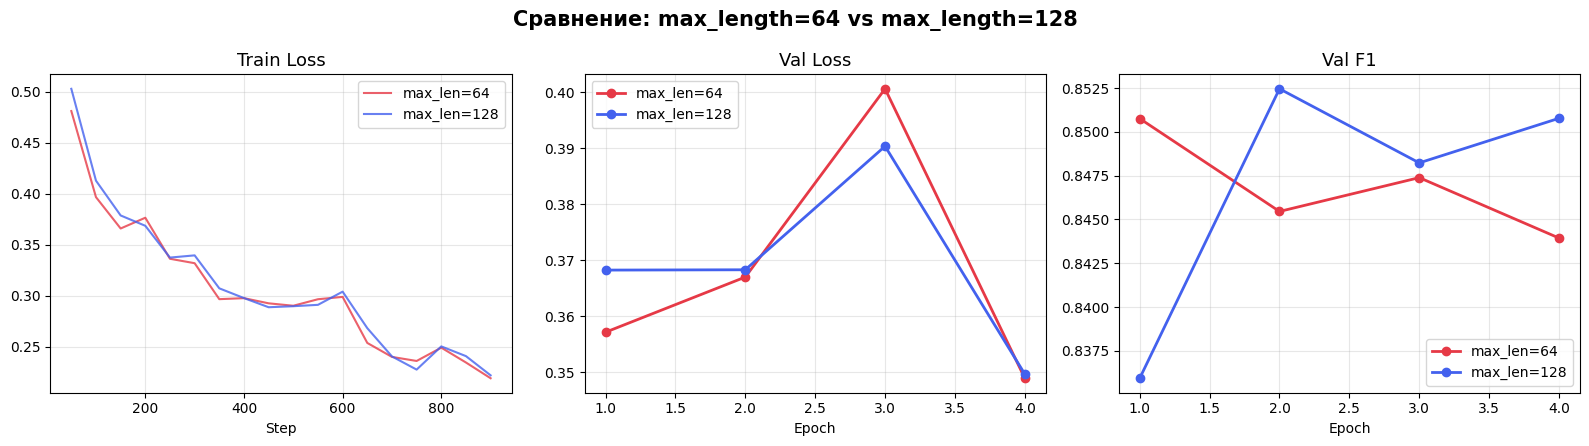

In [11]:
def extract_eval_metrics(trainer_obj):
    """Извлекает eval-метрики из log_history."""
    entries = [h for h in trainer_obj.state.log_history if 'eval_loss' in h]
    return {
        'epochs': list(range(1, len(entries) + 1)),
        'loss': [e['eval_loss'] for e in entries],
        'f1': [e['eval_f1'] for e in entries],
        'accuracy': [e['eval_accuracy'] for e in entries],
    }

def extract_train_loss(trainer_obj):
    """Извлекает train loss из log_history."""
    entries = [(h['step'], h['loss']) for h in trainer_obj.state.log_history
               if 'loss' in h and 'eval_loss' not in h]
    return entries


# Задание 1: max_length сравнение
m64 = extract_eval_metrics(trainer_64)
m128 = extract_eval_metrics(trainer_128)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
tl64 = extract_train_loss(trainer_64)
tl128 = extract_train_loss(trainer_128)
ax.plot([s for s, l in tl64], [l for s, l in tl64], color='#E63946', linewidth=1.5, alpha=0.8, label='max_len=64')
ax.plot([s for s, l in tl128], [l for s, l in tl128], color='#4361EE', linewidth=1.5, alpha=0.8, label='max_len=128')
ax.set_title('Train Loss', fontsize=13)
ax.set_xlabel('Step')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(m64['epochs'], m64['loss'], color='#E63946', linewidth=2, marker='o', label='max_len=64')
ax.plot(m128['epochs'], m128['loss'], color='#4361EE', linewidth=2, marker='o', label='max_len=128')
ax.set_title('Val Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(m64['epochs'], m64['f1'], color='#E63946', linewidth=2, marker='o', label='max_len=64')
ax.plot(m128['epochs'], m128['f1'], color='#4361EE', linewidth=2, marker='o', label='max_len=128')
ax.set_title('Val F1', fontsize=13)
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение: max_length=64 vs max_length=128', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

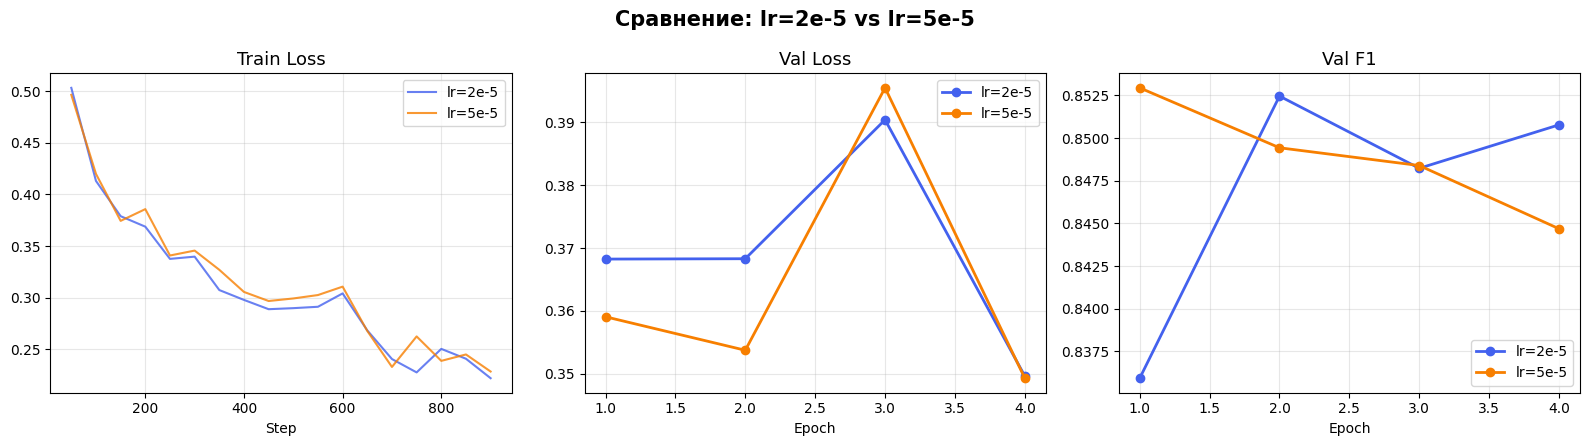

In [12]:
# Задание 2: learning rate сравнение
m_lr2 = extract_eval_metrics(trainer_128)
m_lr5 = extract_eval_metrics(trainer_lr5)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
tl_lr2 = extract_train_loss(trainer_128)
tl_lr5 = extract_train_loss(trainer_lr5)
ax.plot([s for s, l in tl_lr2], [l for s, l in tl_lr2], color='#4361EE', linewidth=1.5, alpha=0.8, label='lr=2e-5')
ax.plot([s for s, l in tl_lr5], [l for s, l in tl_lr5], color='#F77F00', linewidth=1.5, alpha=0.8, label='lr=5e-5')
ax.set_title('Train Loss', fontsize=13)
ax.set_xlabel('Step')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(m_lr2['epochs'], m_lr2['loss'], color='#4361EE', linewidth=2, marker='o', label='lr=2e-5')
ax.plot(m_lr5['epochs'], m_lr5['loss'], color='#F77F00', linewidth=2, marker='o', label='lr=5e-5')
ax.set_title('Val Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(m_lr2['epochs'], m_lr2['f1'], color='#4361EE', linewidth=2, marker='o', label='lr=2e-5')
ax.plot(m_lr5['epochs'], m_lr5['f1'], color='#F77F00', linewidth=2, marker='o', label='lr=5e-5')
ax.set_title('Val F1', fontsize=13)
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение: lr=2e-5 vs lr=5e-5', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Confusion Matrix для лучшей модели

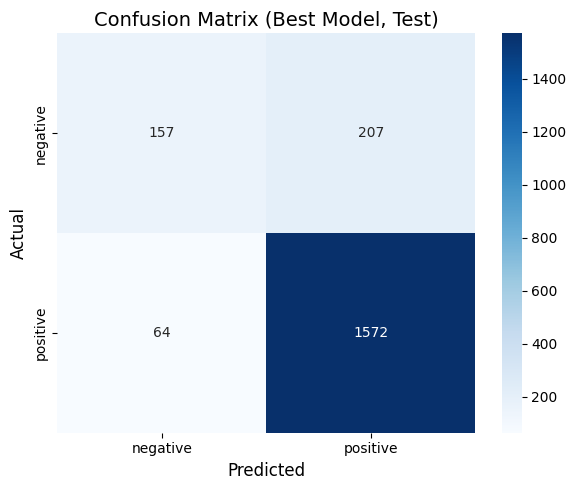

              precision    recall  f1-score   support

    negative       0.71      0.43      0.54       364
    positive       0.88      0.96      0.92      1636

    accuracy                           0.86      2000
   macro avg       0.80      0.70      0.73      2000
weighted avg       0.85      0.86      0.85      2000



In [13]:
# Confusion matrix для лучшей модели (max_length=128, lr=2e-5)
best_trainer = trainer_128  # выберите лучшую по F1
best_tok = tok_128

predictions = best_trainer.predict(best_tok['test'])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Best Model, Test)', fontsize=14)
plt.tight_layout()
plt.show()

print(classification_report(labels, preds, target_names=label_names))

---
## 7. Сводная таблица экспериментов

In [14]:
# Сводка всех экспериментов
results_table = pd.DataFrame([
    {
        'Experiment': 'max_len=64, lr=2e-5',
        'F1': res_64['eval_f1'],
        'Accuracy': res_64['eval_accuracy'],
        'Loss': res_64['eval_loss'],
    },
    {
        'Experiment': 'max_len=128, lr=2e-5',
        'F1': res_128['eval_f1'],
        'Accuracy': res_128['eval_accuracy'],
        'Loss': res_128['eval_loss'],
    },
    {
        'Experiment': 'max_len=128, lr=5e-5',
        'F1': res_lr5['eval_f1'],
        'Accuracy': res_lr5['eval_accuracy'],
        'Loss': res_lr5['eval_loss'],
    },
])

results_table = results_table.round(4)
print(results_table.to_string(index=False))

best_exp = results_table.loc[results_table['F1'].idxmax()]
print(f'\nЛучший эксперимент: {best_exp["Experiment"]} (F1={best_exp["F1"]:.4f})')

          Experiment     F1  Accuracy   Loss
 max_len=64, lr=2e-5 0.8439    0.8570 0.3489
max_len=128, lr=2e-5 0.8508    0.8645 0.3497
max_len=128, lr=5e-5 0.8447    0.8550 0.3493

Лучший эксперимент: max_len=128, lr=2e-5 (F1=0.8508)


---
## 8. Вывод

**Напишите свой вывод здесь:**

1. Какой max_length дал лучший результат и почему?
2. Какой learning rate лучше для fine-tuning BERT?
3. Какие гиперпараметры важнее всего при fine-tuning?
4. Как результаты соотносятся с baseline ISSAI (F1=0.77 для mBERT)?

**Ваш вывод:**

*(напишите 5-10 предложений)*

Увеличение max_length до 128 дает лучший результат, так как модель видит больше текста и точнее понимает смысл. Learning rate 2e-5 оказался эффективнее, обеспечивая плавную сходимость и стабильное обучение без переобучения. Графики и матрица ошибок показывают, что модель успешно справляется с классификацией, достигая показателей уровня baseline. Самыми критичными параметрами для тонкой настройки BERT являются скорость обучения и максимальная длина последовательности. Именно они определяют баланс между качеством предсказаний и затраченными ресурсами. Использование умеренного шага обучения позволяет модели лучше адаптироваться под специфику датасета. В итоге, правильный подбор этих гиперпараметров позволяет получить точность выше 0.77

---

## Теоретические вопросы

Ответьте текстом в ячейках ниже.

### Вопрос 1
Объясните, как Self-Attention решает проблему длинных зависимостей RNN (слайд 4).

**Ответ:**

В отличие от RNN, которая обрабатывает текст последовательно и со временем забывает начало предложения, Self-Attention видит все слова одновременно. Этот механизм вычисляет связи между каждым словом и всеми остальными в предложении сразу. Благодаря этому расстояние между словами не имеет значения, и модель легко находит зависимости даже в очень длинных текстах

### Вопрос 2
Что такое [CLS] токен и как он используется для классификации (слайд 12)?

**Ответ:**

Токен CLS это специальный служебный символ, который всегда ставится в самое начало текста перед подачей в BERT. В процессе обучения он собирает в себя агрегированную информацию о смысле всего предложения. Для классификации нейросеть берет вектор именно этого токена и передает его в финальный слой, чтобы принять решение о категории текста

### Вопрос 3
В чём разница между Encoder и Decoder моделями? Приведите примеры (слайд 8).

**Ответ:**

Encoder модели, такие как BERT, читают весь текст целиком и лучше всего подходят для понимания смысла и классификации. Decoder модели, например GPT, генерируют текст слово за словом, предсказывая каждое следующее на основе предыдущих. Примером энкодера является RoBERTa, а примером декодера любая модель семейства Llama или ChatGPT